In [ ]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler

from torchvision import transforms
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import numpy as np
from collections import Counter
import matplotlib.pyplot as plt
from sklearn.utils.class_weight import compute_class_weight


from tqdm import tqdm
from copy import deepcopy


In [ ]:
rootDir = '/kaggle/input/indoor-scenes-cvpr-2019/indoorCVPR_09/Images'

allData = []
for label in sorted(os.listdir(rootDir)):
    labelDir = os.path.join(rootDir, label)
    if os.path.isdir(labelDir):
        for file in os.listdir(labelDir):
            if file.lower().endswith(('.jpg', '.jpeg', '.png')):
                imgPath = os.path.join(labelDir, file)
                allData.append((imgPath, label))

trainData, tempData = train_test_split(
    allData, test_size=0.2, stratify=[label for _, label in allData], random_state=42
)
valData, testData = train_test_split(
    tempData, test_size=0.5, stratify=[label for _, label in tempData], random_state=42
)

labelNames = sorted(set([label for _, label in allData]))
labelToIndex = {label: idx for idx, label in enumerate(labelNames)}
classNames = labelNames

print(f"Loaded: Train = {len(trainData)}, Val = {len(valData)}, Test = {len(testData)}")


Loaded: Train = 12496, Val = 1562, Test = 1562


In [6]:
mean = [0.485, 0.456, 0.406]
std = [0.229, 0.224, 0.225]
trainTransform = transforms.Compose([
    transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2),
    transforms.RandomAffine(degrees=15, shear=10),
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])


class SceneDataset(Dataset):
    def __init__(self, data, transform=None):
        self.data = data
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        imgPath, label = self.data[idx]
        image = Image.open(imgPath).convert('RGB')
        if self.transform:
            image = self.transform(image)
        return image, labelToIndex[label]



Class Distribution in Train Set:
airport_inside      : 486
artstudio           : 112
auditorium          : 141
bakery              : 324
bar                 : 483
bathroom            : 158
bedroom             : 530
bookstore           : 304
bowling             : 170
buffet              : 89
casino              : 412
children_room       : 90
church_inside       : 144
classroom           : 90
cloister            : 96
closet              : 108
clothingstore       : 85
computerroom        : 91
concert_hall        : 82
corridor            : 277
deli                : 206
dentaloffice        : 105
dining_room         : 218
elevator            : 81
fastfood_restaurant : 93
florist             : 82
gameroom            : 102
garage              : 82
greenhouse          : 81
grocerystore        : 170
gym                 : 185
hairsalon           : 191
hospitalroom        : 81
inside_bus          : 82
inside_subway       : 366
jewelleryshop       : 126
kindergarden        : 101
kitchen           

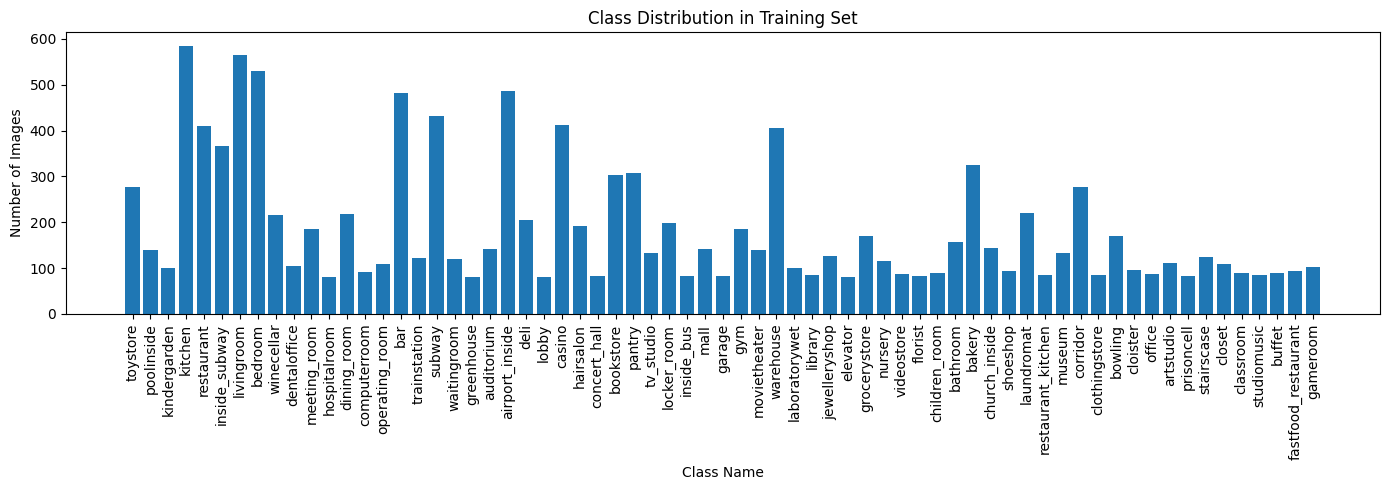

In [ ]:


trainLabels = [label for _, label in trainData]
labelCounts = Counter(trainLabels)

print("\nClass Distribution in Train Set:")
for cls in sorted(labelCounts):
    print(f"{cls:20s}: {labelCounts[cls]}")

plt.figure(figsize=(14, 5))
plt.bar(labelCounts.keys(), labelCounts.values())
plt.xticks(rotation=90)
plt.title("Class Distribution in Training Set")
plt.xlabel("Class Name")
plt.ylabel("Number of Images")
plt.tight_layout()
plt.show()



Class Distribution in Val Set:
airport_inside      : 61
artstudio           : 14
auditorium          : 17
bakery              : 40
bar                 : 60
bathroom            : 19
bedroom             : 66
bookstore           : 38
bowling             : 21
buffet              : 11
casino              : 51
children_room       : 11
church_inside       : 18
classroom           : 12
cloister            : 12
closet              : 14
clothingstore       : 11
computerroom        : 12
concert_hall        : 11
corridor            : 34
deli                : 26
dentaloffice        : 13
dining_room         : 27
elevator            : 10
fastfood_restaurant : 12
florist             : 11
gameroom            : 13
garage              : 11
greenhouse          : 10
grocerystore        : 21
gym                 : 23
hairsalon           : 24
hospitalroom        : 10
inside_bus          : 10
inside_subway       : 45
jewelleryshop       : 16
kindergarden        : 13
kitchen             : 73
laboratorywet     

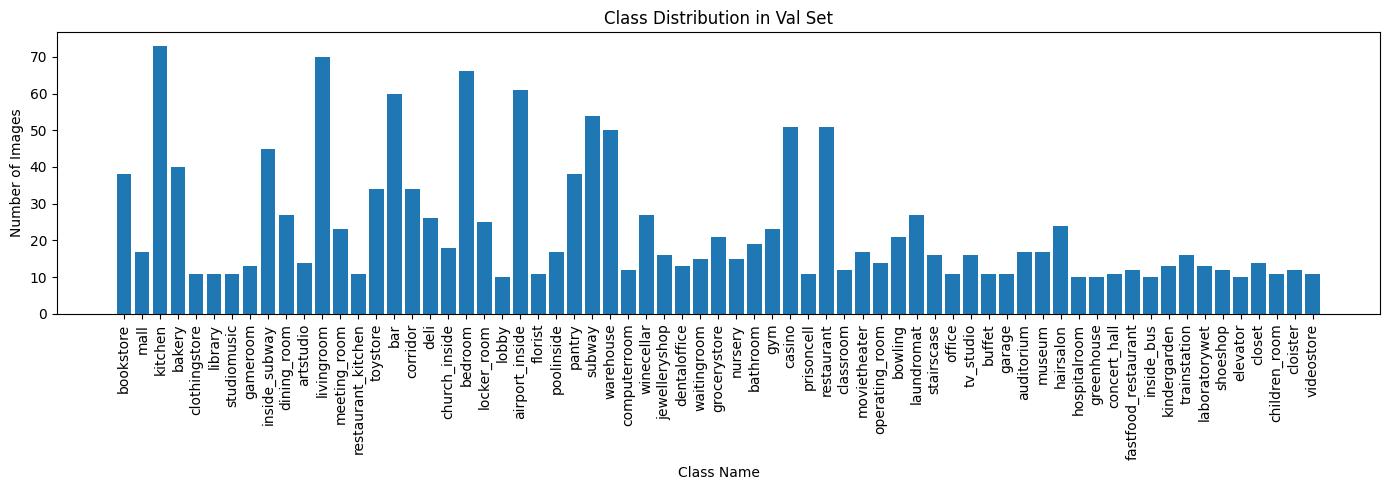

In [ ]:


valLabels = [label for _, label in valData]
labelCounts = Counter(valLabels)

print("\nClass Distribution in Val Set:")
for cls in sorted(labelCounts):
    print(f"{cls:20s}: {labelCounts[cls]}")

plt.figure(figsize=(14, 5))
plt.bar(labelCounts.keys(), labelCounts.values())
plt.xticks(rotation=90)
plt.title("Class Distribution in Val Set")
plt.xlabel("Class Name")
plt.ylabel("Number of Images")
plt.tight_layout()
plt.show()


Class Distribution in Val Set:
airport_inside      : 61
artstudio           : 14
auditorium          : 18
bakery              : 41
bar                 : 61
bathroom            : 20
bedroom             : 66
bookstore           : 38
bowling             : 22
buffet              : 11
casino              : 52
children_room       : 11
church_inside       : 18
classroom           : 11
cloister            : 12
closet              : 13
clothingstore       : 10
computerroom        : 11
concert_hall        : 10
corridor            : 35
deli                : 26
dentaloffice        : 13
dining_room         : 28
elevator            : 10
fastfood_restaurant : 11
florist             : 10
gameroom            : 12
garage              : 10
greenhouse          : 10
grocerystore        : 22
gym                 : 23
hairsalon           : 24
hospitalroom        : 10
inside_bus          : 10
inside_subway       : 46
jewelleryshop       : 15
kindergarden        : 12
kitchen             : 74
laboratorywet     

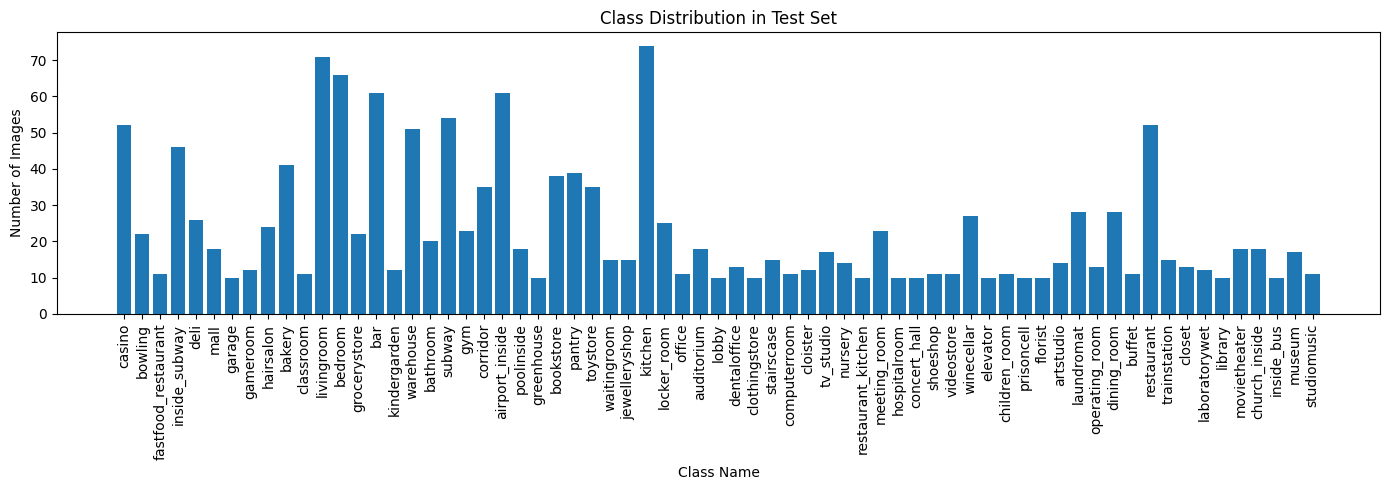

In [ ]:


testLabels = [label for _, label in testData]
labelCounts = Counter(testLabels)

print("\nClass Distribution in Val Set:")
for cls in sorted(labelCounts):
    print(f"{cls:20s}: {labelCounts[cls]}")

plt.figure(figsize=(14, 5))
plt.bar(labelCounts.keys(), labelCounts.values())
plt.xticks(rotation=90)
plt.title("Class Distribution in Test Set")
plt.xlabel("Class Name")
plt.ylabel("Number of Images")
plt.tight_layout()
plt.show()

In [10]:
batchSize = 64

trainDataset = SceneDataset(trainData, trainTransform)
valDataset = SceneDataset(valData, transform)
testDataset = SceneDataset(testData, transform)

trainLoader = DataLoader(trainDataset, batch_size=batchSize, shuffle=True)
valLoader = DataLoader(valDataset, batch_size=batchSize, shuffle=False)
testLoader = DataLoader(testDataset, batch_size=batchSize, shuffle=False)

classNames = labelNames


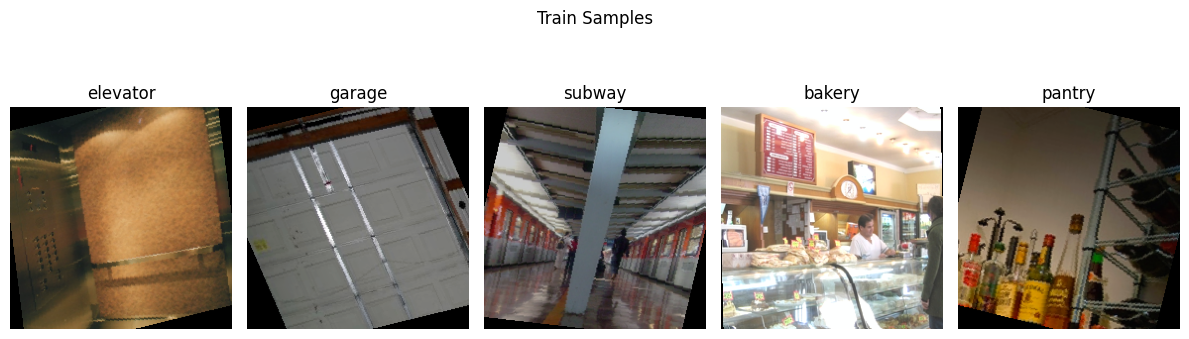

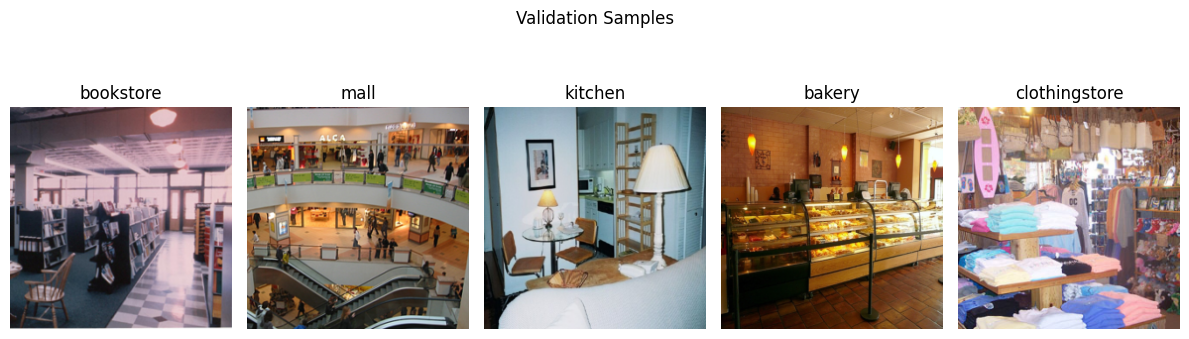

In [11]:

def showSamples(dataLoader, classNames, title="Sample Images"):
    images, labels = next(iter(dataLoader))
    plt.figure(figsize=(12, 4))
    for i in range(5):
        img = images[i].permute(1, 2, 0).numpy()  # Convert CHW → HWC
        img = img * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])  # Unnormalize
        img = np.clip(img, 0, 1)
        plt.subplot(1, 5, i+1)
        plt.imshow(img)
        plt.title(classNames[labels[i].item()])
        plt.axis('off')
    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

showSamples(trainLoader, classNames, title="Train Samples")
showSamples(valLoader, classNames, title="Validation Samples")


In [ ]:
import torch
import torch.nn as nn

#Dense Layer
class DenseLayer(nn.Module):
    def __init__(self, in_channels, growth_rate):
        super(DenseLayer, self).__init__()
        self.bn = nn.BatchNorm2d(in_channels)
        self.relu = nn.ReLU(inplace=True)
        self.conv = nn.Conv2d(in_channels, growth_rate, kernel_size=3, padding=1, bias=False)

    def forward(self, x):
        out = self.conv(self.relu(self.bn(x)))
        return torch.cat([x, out], 1)  

#Dense Block
class DenseBlock(nn.Module):
    def __init__(self, num_layers, in_channels, growth_rate):
        super(DenseBlock, self).__init__()
        layers = []
        for i in range(num_layers):
            layers.append(DenseLayer(in_channels + i * growth_rate, growth_rate))
        self.block = nn.Sequential(*layers)

    def forward(self, x):
        return self.block(x)

#Transition Layer
class TransitionLayer(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(TransitionLayer, self).__init__()
        self.layer = nn.Sequential(
            nn.BatchNorm2d(in_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(in_channels, out_channels, kernel_size=1, bias=False),
            nn.AvgPool2d(2)
        )

    def forward(self, x):
        return self.layer(x)

#Full DenseNet
class DenseNetLikeSceneClassifier(nn.Module):
    def __init__(self, growth_rate=32, block_layers=[4, 6, 8], num_classes=67):
        super(DenseNetLikeSceneClassifier, self).__init__()

        self.stem = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=7, stride=2, padding=3, bias=False),  # Conv
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(3, stride=2, padding=1)  # Pool
        )

        #Dense Blocks + Transitions
        self.features = nn.Sequential()
        num_channels = 64
        for i, num_layers in enumerate(block_layers):
            block = DenseBlock(num_layers, num_channels, growth_rate)
            self.features.add_module(f'denseblock{i+1}', block)
            num_channels = num_channels + num_layers * growth_rate
            if i != len(block_layers) - 1:  
                trans = TransitionLayer(num_channels, num_channels // 2)
                self.features.add_module(f'transition{i+1}', trans)
                num_channels = num_channels // 2

        #Final batch norm
        self.bn_final = nn.BatchNorm2d(num_channels)

        #Classifier
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d((1, 1)),
            nn.Flatten(),
            nn.Linear(num_channels, num_classes)
        )

    def forward(self, x):
        x = self.stem(x)
        x = self.features(x)
        x = self.bn_final(x)
        x = self.classifier(x)
        return x


In [15]:
from torchinfo import summary

#device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = DenseNetLikeSceneClassifier(
    growth_rate=32,
    block_layers=[6, 12, 24, 16],
    num_classes=67
)


summary(model, input_size=(1, 3, 224, 224))


Layer (type:depth-idx)                        Output Shape              Param #
DenseNetLikeSceneClassifier                   [1, 67]                   --
├─Sequential: 1-1                             [1, 64, 56, 56]           --
│    └─Conv2d: 2-1                            [1, 64, 112, 112]         9,408
│    └─BatchNorm2d: 2-2                       [1, 64, 112, 112]         128
│    └─ReLU: 2-3                              [1, 64, 112, 112]         --
│    └─MaxPool2d: 2-4                         [1, 64, 56, 56]           --
├─Sequential: 1-2                             [1, 1024, 7, 7]           --
│    └─DenseBlock: 2-5                        [1, 256, 56, 56]          --
│    │    └─Sequential: 3-1                   [1, 256, 56, 56]          250,560
│    └─TransitionLayer: 2-6                   [1, 128, 28, 28]          --
│    │    └─Sequential: 3-2                   [1, 128, 28, 28]          33,280
│    └─DenseBlock: 2-7                        [1, 512, 28, 28]          --
│    │ 

In [ ]:


trainEncodedLabels = [labelToIndex[label] for _, label in trainData]

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(trainEncodedLabels),
    y=trainEncodedLabels
)

class_weights = torch.tensor(class_weights, dtype=torch.float)


In [ ]:
#weighted cross entropy loss
criterion = nn.CrossEntropyLoss(
    weight=class_weights,
    label_smoothing=0.1
)

# Optimizer and scheduler
optimizer = torch.optim.AdamW(model.parameters(), lr=2e-4, weight_decay=5e-5)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=120)
earlyStopPatience = 15
batchSize = 64


In [ ]:
import time

def trainModel(model, trainLoader, valLoader, criterion, optimizer, scheduler, epochs=80, earlyStopPatience=5):
    bestValAcc = 0
    patienceCounter = 0

    trainAccList, valAccList, trainLossList, valLossList = [], [], [], []

    for epoch in range(epochs):
        start_time = time.time()

        model.train()
        totalTrainLoss, correctTrain, totalTrain = 0, 0, 0

        for images, labels in trainLoader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            totalTrainLoss += loss.item()
            _, preds = outputs.max(1)
            correctTrain += (preds == labels).sum().item()
            totalTrain += labels.size(0)

        trainAcc = correctTrain / totalTrain
        trainLoss = totalTrainLoss / len(trainLoader)

        valLoss, valAcc = evaluateModel(model, valLoader, criterion)

        trainAccList.append(trainAcc)
        valAccList.append(valAcc)
        trainLossList.append(trainLoss)
        valLossList.append(valLoss)

        scheduler.step()

        elapsed_time = time.time() - start_time
        print(f"Current LR: {scheduler.get_last_lr()[0]:.6f}")
        print(f"Epoch {epoch+1:02d} | Train Acc: {trainAcc:.4f} | Val Acc: {valAcc:.4f} | "
              f"Train Loss: {trainLoss:.4f} | Val Loss: {valLoss:.4f} | Time: {elapsed_time:.2f}s")

        if valAcc > bestValAcc:
            bestValAcc = valAcc
            patienceCounter = 0
            torch.save(model.state_dict(),"bestModelLatest.pth")
        else:
            patienceCounter += 1
            if patienceCounter >= earlyStopPatience:
                print("Early stopping triggered.")
                break

    return trainAccList, valAccList, trainLossList, valLossList


In [ ]:

def evaluateModel(model, dataLoader, criterion):
    model.eval()
    totalLoss, correct, total = 0.0, 0, 0

    with torch.no_grad():
        for images, labels in dataLoader:
            images, labels = images, labels
            outputs = model(images)
            loss = criterion(outputs, labels)

            totalLoss += loss.item()
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    avgLoss = totalLoss / len(dataLoader)
    accuracy = correct / total
    return avgLoss, accuracy

In [ ]:
trainAccList, valAccList, trainLossList, valLossList = trainModel(
    model, trainLoader, valLoader, criterion, optimizer, scheduler,
    epochs=120, earlyStopPatience=earlyStopPatience
)


In [ ]:

def plotAccuracyLoss(trainAccList, valAccList, trainLossList, valLossList):
    Epochs = range(1, len(trainAccList) + 1)

    #Accuracy Plot
    plt.figure(figsize=(10, 4))
    plt.subplot(1, 2, 1)
    plt.plot(Epochs, trainAccList, label='TrainAccuracy', marker='o')
    plt.plot(Epochs, valAccList, label='ValidationAccuracy', marker='o')
    plt.title('Accuracy Over Epochs')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()

    #Loss Plot
    plt.subplot(1, 2, 2)
    plt.plot(Epochs, trainLossList, label='TrainLoss', marker='o')
    plt.plot(Epochs, valLossList, label='ValidationLoss', marker='o')
    plt.title('Loss Over Epochs')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    plt.tight_layout()
    plt.show()

plotAccuracyLoss(trainAccList, valAccList, trainLossList, valLossList)


In [ ]:
model.load_state_dict(torch.load("/kaggle/input/bestmodel/pytorch/default/1/bestModel.pth",map_location=torch.device('cpu')))


testLoss, testAcc = evaluateModel(model, testLoader, criterion)
print(f"Test Accuracy: {testAcc*100:.4f} Test Loss: {testLoss:.4f}")

Test Accuracy: 62.0999 Test Loss: 2.2637


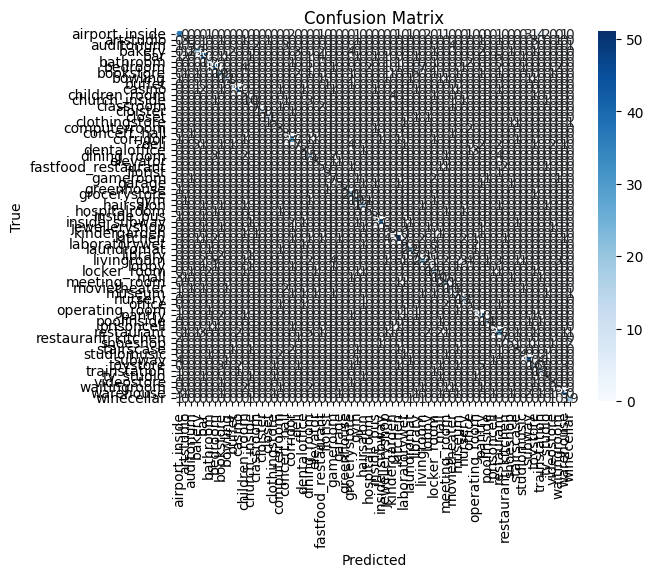

                     precision    recall  f1-score   support

     airport_inside       0.60      0.61      0.60        61
          artstudio       0.27      0.21      0.24        14
         auditorium       0.50      0.29      0.37        17
             bakery       0.73      0.54      0.62        41
                bar       0.68      0.64      0.66        61
           bathroom       0.58      0.55      0.56        20
            bedroom       0.66      0.59      0.62        66
          bookstore       0.56      0.50      0.53        38
            bowling       0.80      0.55      0.65        22
             buffet       0.67      0.73      0.70        11
             casino       0.89      0.76      0.82        51
      children_room       0.25      0.45      0.32        11
      church_inside       0.59      0.56      0.57        18
          classroom       0.70      0.64      0.67        11
           cloister       1.00      0.92      0.96        12
             closet    

In [ ]:
allLabels, allPreds = [], []
model.eval()
with torch.no_grad():
    for images, labels in testLoader:
        images = images
        outputs = model(images)
        _, preds = outputs.max(1)
        allLabels.extend(labels.cpu().numpy())
        allPreds.extend(preds.cpu().numpy())

cm = confusion_matrix(allLabels, allPreds)
sns.heatmap(cm, annot=True, fmt='d', xticklabels=classNames, yticklabels=classNames, cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()
report_dict = classification_report(allLabels, allPreds, target_names=classNames, output_dict=True)
print(classification_report(allLabels, allPreds, target_names=classNames))


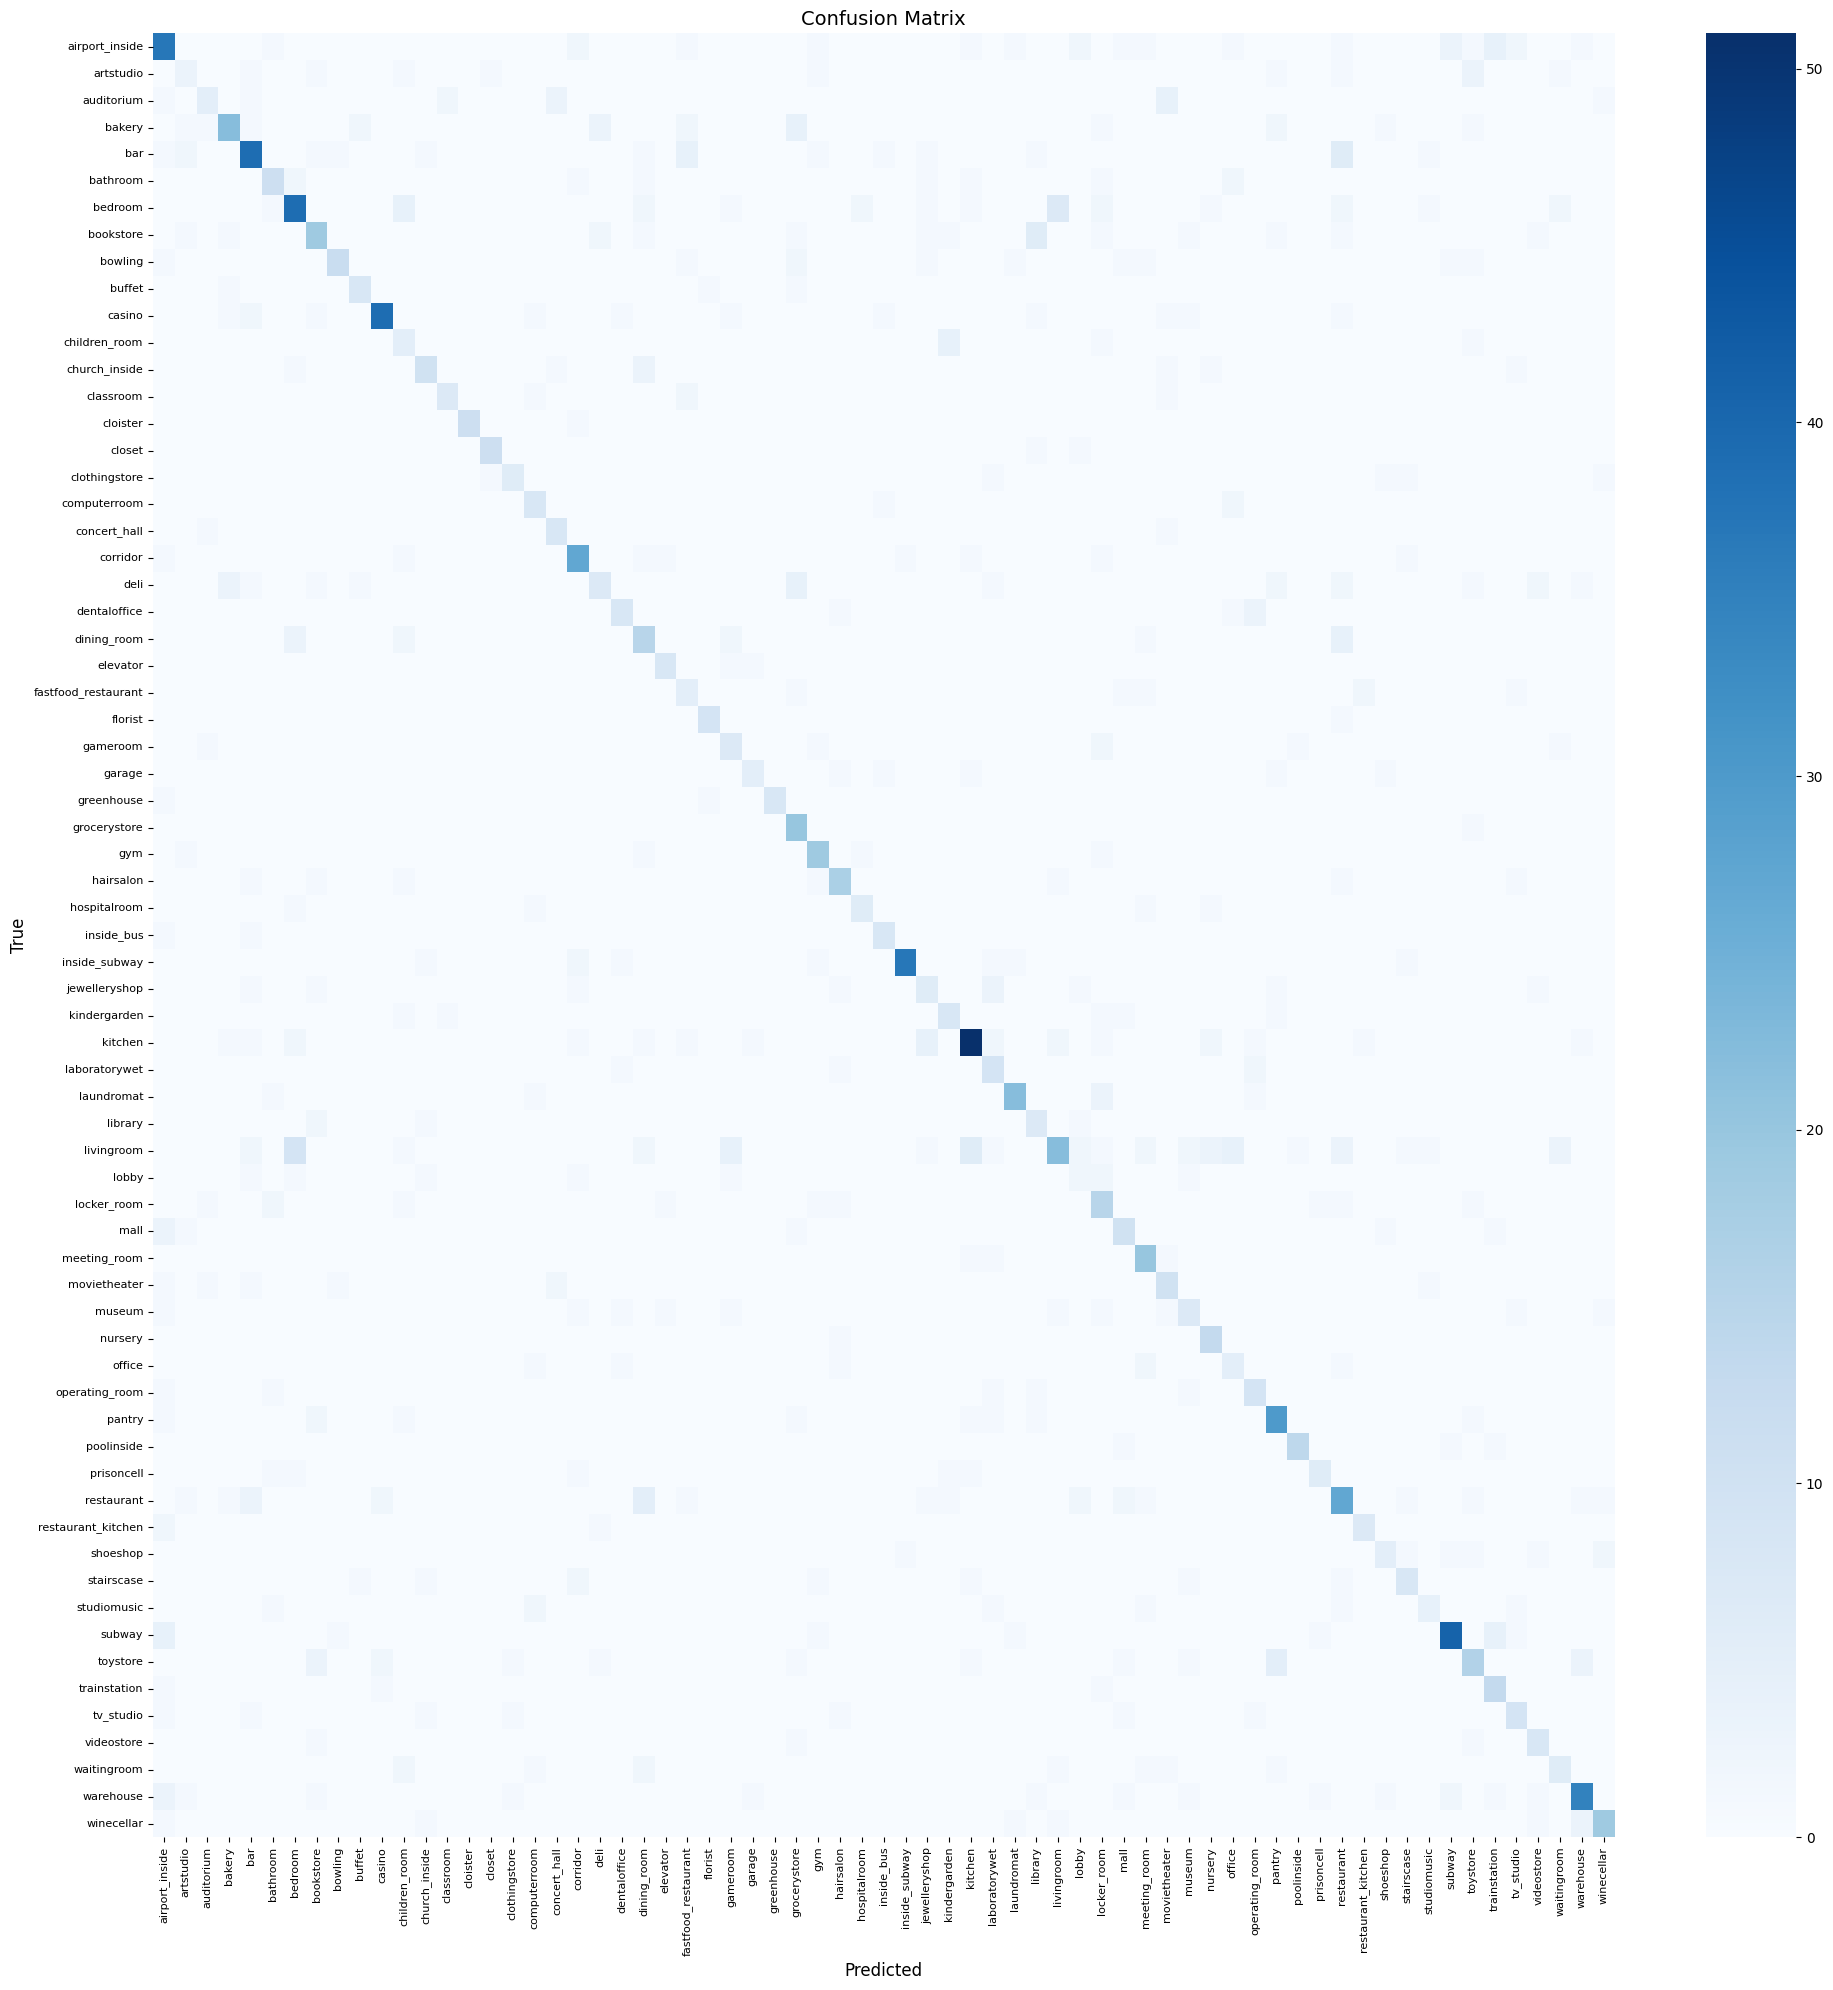

In [ ]:

cm = confusion_matrix(allLabels, allPreds)

plt.figure(figsize=(20, 20))

sns.heatmap(cm, cmap='Blues', xticklabels=classNames, yticklabels=classNames)

plt.xticks(rotation=90, fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.xlabel("Predicted", fontsize=12)
plt.ylabel("True", fontsize=12)
plt.title("Confusion Matrix", fontsize=14)
plt.tight_layout()
plt.show()


Performance finetunement

In [ ]:

df_report = pd.DataFrame(report_dict).transpose()
df_report = df_report.round(2)
low_f1 = df_report[df_report['f1-score'] < 0.45]
print("Low performing classes:\n", low_f1)


Low performing classes:
                      precision  recall  f1-score  support
artstudio                 0.27    0.21      0.24     14.0
auditorium                0.50    0.29      0.37     17.0
children_room             0.25    0.45      0.32     11.0
deli                      0.50    0.27      0.35     26.0
fastfood_restaurant       0.29    0.45      0.36     11.0
jewelleryshop             0.35    0.38      0.36     16.0
livingroom                0.63    0.31      0.42     71.0
lobby                     0.18    0.20      0.19     10.0
museum                    0.44    0.41      0.42     17.0
office                    0.33    0.45      0.38     11.0
studiomusic               0.50    0.36      0.42     11.0
waitingroom               0.46    0.40      0.43     15.0


In [ ]:


labelCounts = Counter([label for _, label in trainData])

report_dict = classification_report(allLabels, allPreds, target_names=classNames, output_dict=True)

df_report = pd.DataFrame(report_dict).transpose().round(2)

df_report = df_report.loc[classNames]

df_report['train_count'] = df_report.index.map(lambda cls: labelCounts.get(cls, 0))

low_f1_df = df_report[df_report['f1-score'] < 0.45]

print("\nLow Performing Classes (F1-score < 0.45):")
print(low_f1_df[['train_count', 'f1-score']])



Low Performing Classes (F1-score < 0.45):
                     train_count  f1-score
artstudio                    112      0.24
auditorium                   141      0.37
children_room                 90      0.32
deli                         206      0.35
fastfood_restaurant           93      0.36
jewelleryshop                126      0.36
livingroom                   565      0.42
lobby                         81      0.19
museum                       134      0.42
office                        87      0.38
studiomusic                   86      0.42
waitingroom                  121      0.43


In [ ]:
num_low_f1_classes = len(low_f1_df)
print(num_low_f1_classes)
low_f1_classes_names = low_f1_df.index.tolist()

print(low_f1_classes_names)

12
['artstudio', 'auditorium', 'children_room', 'deli', 'fastfood_restaurant', 'jewelleryshop', 'livingroom', 'lobby', 'museum', 'office', 'studiomusic', 'waitingroom']


In [ ]:


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# low_f1_classes = ['artstudio', 'deli', 'elevator', 'library', 'lobby', 'museum']
low_f1_classes = low_f1_classes_names
strong_transform = transforms.Compose([
    transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.RandomApply([transforms.ColorJitter(), transforms.RandomRotation(25)], p=0.5),
    transforms.ToTensor()
])

default_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

class CustomSceneDataset(Dataset):
    def __init__(self, data, label_map, transform_map):
        self.data = data
        self.label_map = label_map
        self.transform_map = transform_map

    def __getitem__(self, index):
        img_path, label_name = self.data[index]
        image = Image.open(img_path).convert("RGB")
        transform = self.transform_map.get(label_name, default_transform)
        image = transform(image)
        label = self.label_map[label_name]
        return image, label

    def __len__(self):
        return len(self.data)

#DataPrep
filtered_train = [(img, label) for img, label in trainData if label in low_f1_classes]
filtered_val = [(img, label) for img, label in valData if label in low_f1_classes]

fine_label_names = sorted(set(label for _, label in filtered_train))
fine_label_to_idx = {label: idx for idx, label in enumerate(fine_label_names)}
idx_to_fine_label = {v: k for k, v in fine_label_to_idx.items()}
num_low_f1_classes = len(fine_label_names)

transform_map = {cls: strong_transform for cls in low_f1_classes}

train_ds = CustomSceneDataset(filtered_train, fine_label_to_idx, transform_map)
val_ds = CustomSceneDataset(filtered_val, fine_label_to_idx, transform_map)

class_counts = {cls: 0 for cls in fine_label_names}
for _, label in filtered_train:
    class_counts[label] += 1

sample_weights = [1.0 / class_counts[label] for _, label in filtered_train]
sampler = WeightedRandomSampler(sample_weights, len(sample_weights), replacement=True)

train_loader = DataLoader(train_ds, batch_size=32, sampler=sampler, num_workers=2)
val_loader = DataLoader(val_ds, batch_size=32, shuffle=False, num_workers=2)

finetune_model = deepcopy(model)


finetune_model.classifier = nn.Sequential(
    nn.AdaptiveAvgPool2d((1, 1)),
    nn.Flatten(),
    nn.Linear(1024, num_low_f1_classes)
)

finetune_model = finetune_model.to(device)

#Loss and Optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(finetune_model.parameters(), lr=1e-4)

#Training Loop
def train_finetune_model(model, train_loader, val_loader, num_epochs, device):
    for epoch in range(num_epochs):
        model.train()
        running_loss, correct, total = 0.0, 0, 0
        loop = tqdm(train_loader, desc=f"Epoch [{epoch+1}/{num_epochs}]")

        for imgs, labels in loop:
            imgs, labels = imgs.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            # Metrics
            running_loss += loss.item() * imgs.size(0)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

            loop.set_postfix(loss=loss.item(), acc=100. * correct / total)

        print(f"\nEpoch [{epoch+1}] - Loss: {running_loss/total:.4f}, Acc: {100.*correct/total:.2f}%")

        evaluate_finetune_model(model, val_loader, device)

#Evaluation
def evaluate_finetune_model(model, val_loader, device):
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for imgs, labels in val_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model(imgs)
            _, preds = outputs.max(1)
            total += labels.size(0)
            correct += preds.eq(labels).sum().item()
    acc = 100. * correct / total
    print(f"Validation Accuracy: {acc:.2f}%")
    model.train()

train_finetune_model(finetune_model, train_loader, val_loader, num_epochs=20, device=device)


Epoch [1/20]: 100%|██████████| 58/58 [09:44<00:00, 10.08s/it, acc=59.3, loss=1.02] 


Epoch [1] - Loss: 1.4939, Acc: 59.28%


Validation Accuracy: 48.70%


Epoch [2/20]: 100%|██████████| 58/58 [09:29<00:00,  9.81s/it, acc=75.7, loss=0.578]


Epoch [2] - Loss: 0.8728, Acc: 75.73%


...


Epoch [19] - Loss: 0.3609, Acc: 88.44%


Validation Accuracy: 52.61%


Epoch [20/20]: 100%|██████████| 58/58 [09:50<00:00, 10.18s/it, acc=87.4, loss=0.653]


Epoch [20] - Loss: 0.4031, Acc: 87.35%


Validation Accuracy: 59.57%


In [ ]:

#finetuned model evaluation
finetune_model.eval()
y_true_new, y_pred_new = [], []

with torch.no_grad():
    for imgs, labels in val_loader:  
        imgs, labels = imgs.to(device), labels.to(device)
        outputs = finetune_model(imgs)
        _, preds = torch.max(outputs, 1)
        y_true_new.extend(labels.cpu().numpy())
        y_pred_new.extend(preds.cpu().numpy())

target_names = list(fine_label_to_idx.keys())
df_report_after = classification_report(
    y_true_new, y_pred_new, target_names=target_names, output_dict=True
)
df_report_after = pd.DataFrame(df_report_after).transpose()

f1_before = df_report.loc[target_names, "f1-score"]
f1_after = df_report_after.loc[target_names, "f1-score"]
comparison_df = pd.DataFrame({
    "F1-Before": f1_before,
    "F1-After": f1_after,
    "Delta": f1_after - f1_before
})

print("\n F1-score Comparison (Before vs After Fine-tuning):")
print(comparison_df)



 F1-score Comparison (Before vs After Fine-tuning):
                     F1-Before  F1-After     Delta
artstudio                 0.24  0.500000  0.260000
auditorium                0.37  0.848485  0.478485
children_room             0.32  0.625000  0.305000
deli                      0.35  0.711864  0.361864
fastfood_restaurant       0.36  0.250000 -0.110000
jewelleryshop             0.36  0.551724  0.191724
livingroom                0.42  0.788321  0.368321
lobby                     0.19  0.285714  0.095714
museum                    0.42  0.482759  0.062759
office                    0.38  0.347826 -0.032174
studiomusic               0.42  0.818182  0.398182
waitingroom               0.43  0.400000 -0.030000


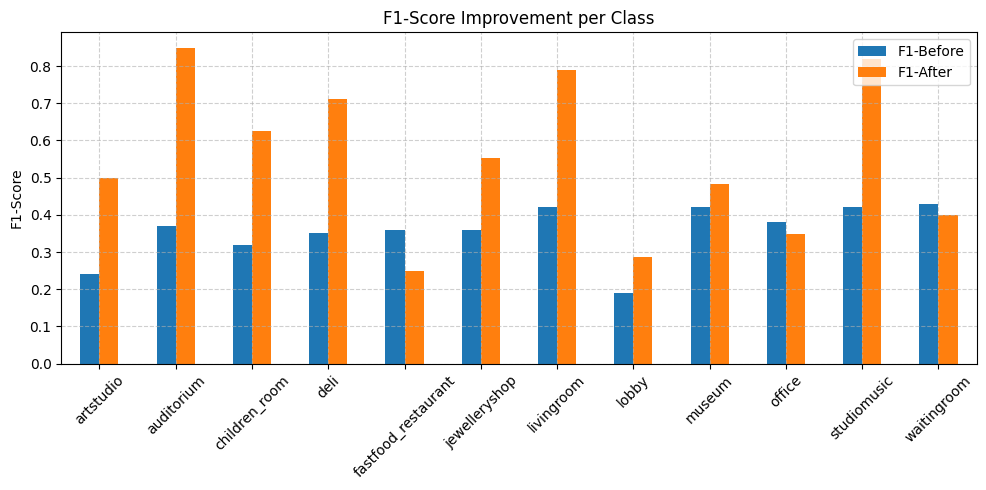

In [ ]:

comparison_df[["F1-Before", "F1-After"]].plot(kind="bar", figsize=(10, 5))
plt.title("F1-Score Improvement per Class")
plt.ylabel("F1-Score")
plt.xticks(rotation=45)
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()
